## Life Expectancy Drugs-Target Interaction Matrix Completion
* Author(s): Safa Beydoun and Morgen Henry
* Date: January 2026

In [2]:
# All Necessary imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem
from rdkit.Chem import DataStructs
import requests
import numpy as np
import selfies as sf
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output, remove if needed for debugging

### Data Loading & Preliminary View

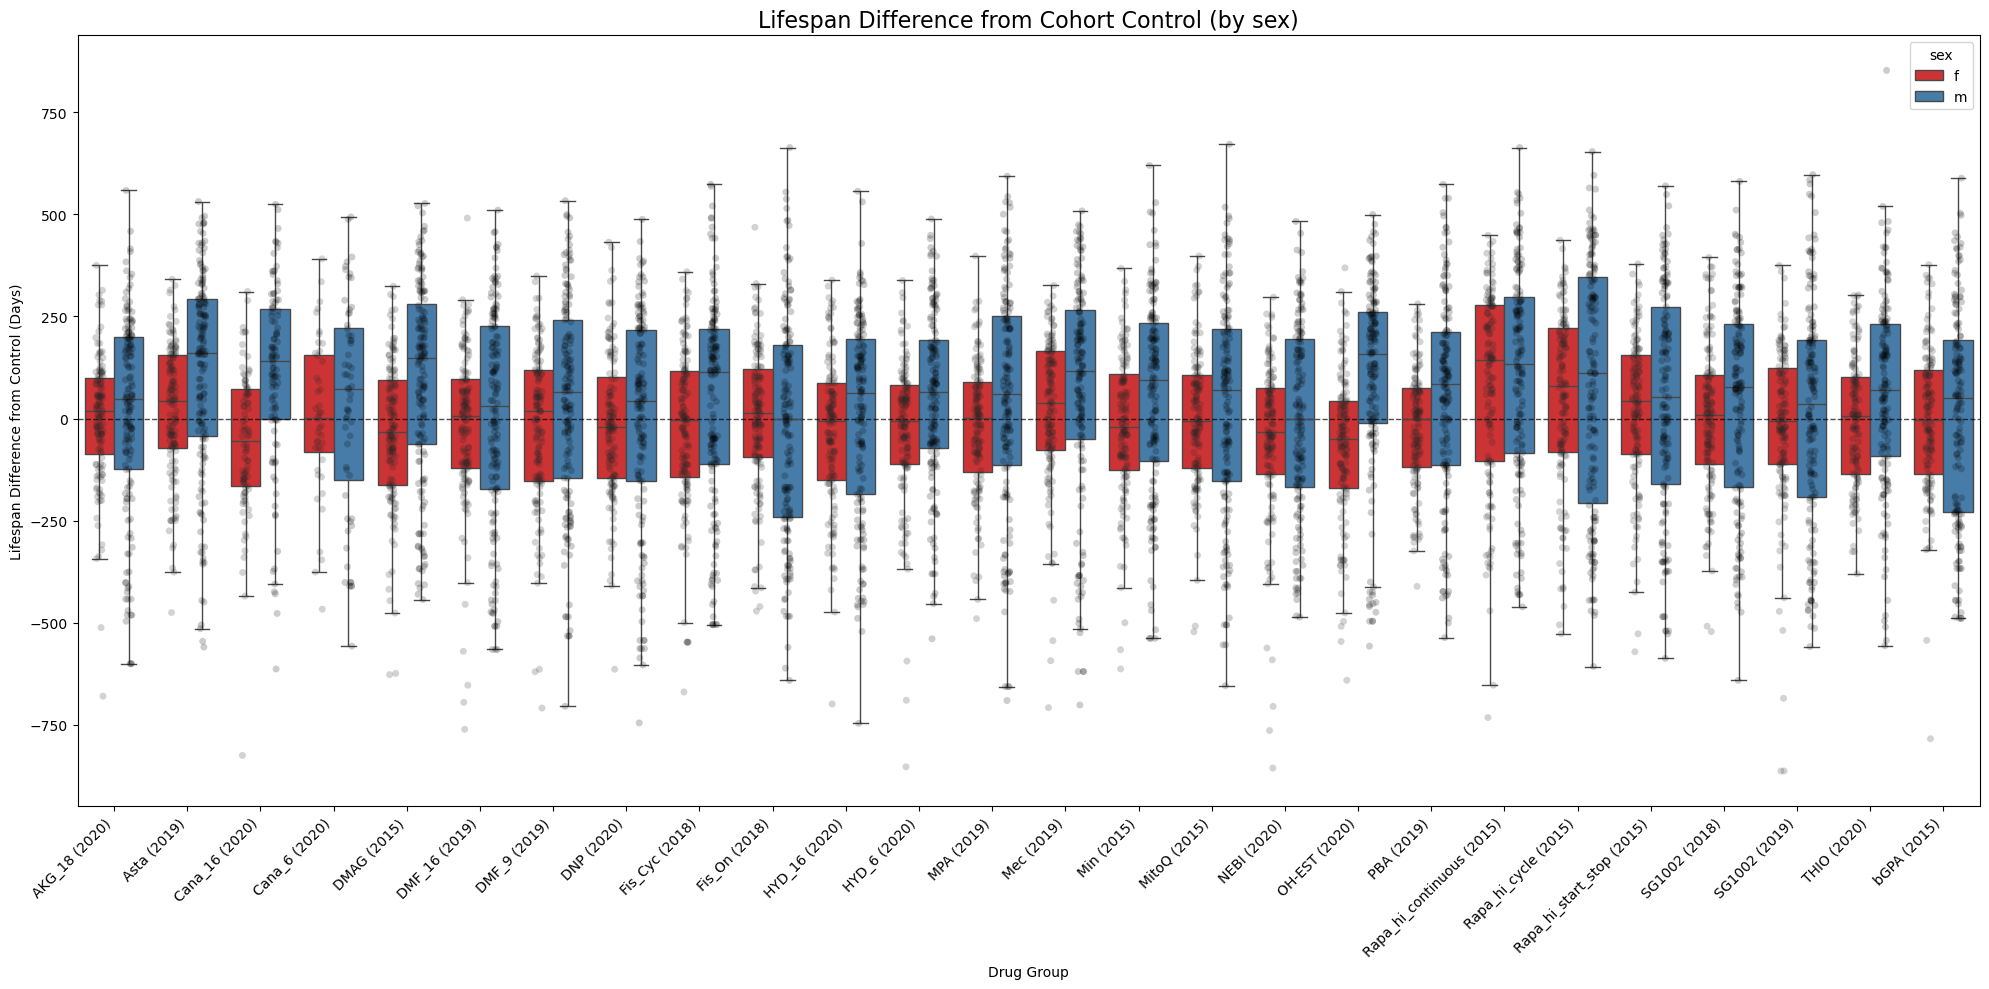

In [5]:
# Read in the data from the XLSX files
file_path_2020 = 'ITP_C2020_Lifespan.xlsx'
c2020_data = pd.read_excel(file_path_2020)
c2020_data = c2020_data.rename(columns={'age(days)': 'age'})

file_path_2019 = 'ITP_C2019_Lifespan.xlsx'
c2019_data = pd.read_excel(file_path_2019)
c2019_data = c2019_data.rename(columns={'age(days)': 'age'})

file_path_2018= 'ITP_C2018_Lifespan.xlsx'
c2018_data = pd.read_excel(file_path_2018)
c2018_data = c2018_data.rename(columns={'age(days)': 'age'})

file_path_2015 = 'ITP_C2015_Lifespan.xlsx'
c2015_data = pd.read_excel(file_path_2015)

# Combine Data
c2015_data['cohort'] = '2015'
c2019_data['cohort'] = '2019'
c2020_data['cohort'] = '2020'
c2018_data['cohort'] = '2018'
combined_df = pd.concat([c2015_data, c2019_data, c2020_data, c2018_data], ignore_index=True)

# Create unique labels for drugs to avoid confusion
combined_df['group_label'] = combined_df['group'] + " (" + combined_df['cohort'] + ")"

# Define order: Put Controls first, then sorted drugs
drug_groups = sorted([g for g in combined_df['group_label'].unique() if 'Control' not in g])
control_groups = sorted([g for g in combined_df['group_label'].unique() if 'Control' in g])
plot_order = control_groups + drug_groups

# Compute control mean per cohort and sex
control_means = (
    combined_df[combined_df['group'].str.contains('Control', case=False)]
    .groupby(['cohort', 'sex'])['age']
    .mean()
    .rename('control_mean')
    .reset_index()
)

# Merge back and compute difference from control
combined_df = combined_df.merge(control_means, on=['cohort', 'sex'], how='left')
combined_df['age_diff'] = combined_df['age'] - combined_df['control_mean']

# Drop controls from the plot (they're the reference, centered at 0)
plot_df = combined_df[~combined_df['group'].str.contains('Control', case=False)].copy()
drug_order = sorted(plot_df['group_label'].unique())

# ==========================================
# Visualization
# ==========================================
plt.figure(figsize=(20, 10))
ax = sns.boxplot(data=plot_df, x='group_label', y='age_diff', hue='sex',
                 order=drug_order, palette='Set1', fliersize=0)
sns.stripplot(data=plot_df, x='group_label', y='age_diff', hue='sex',
              order=drug_order, dodge=True, color='black', alpha=0.2, jitter=True, legend=False)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title('Lifespan Difference from Cohort Control (by sex)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Lifespan Difference from Control (Days)')
plt.xlabel('Drug Group')
plt.tight_layout()
plt.show()

In [9]:
for year, df in [('2015', c2015_data), ('2018', c2018_data),
                 ('2019', c2019_data), ('2020', c2020_data)]:
    print(f"\nC{year}:")
    counts = df.groupby(['group', 'sex']).size().unstack(fill_value=0)
    print(counts)


C2015:
sex                   f    m
group                       
Control             280  300
DMAG                136  156
Min                 136  156
MitoQ               136  156
Rapa_hi_continuous  136  156
Rapa_hi_cycle       136  159
Rapa_hi_start_stop  136  153
bGPA                136  156

C2018:
sex        f    m
group            
Control  288  318
Fis_Cyc  144  156
Fis_On   144  159
SG1002   144  156

C2019:
sex        f    m
group            
Asta     136  156
Control  284  311
DMF_16   136  156
DMF_9    135  156
MPA      136  156
Mec      136  155
PBA      136  155
SG1002   135  156

C2020:
sex        f    m
group            
AKG_18   132  153
Cana_16   92  102
Cana_6    44   60
Control  272  303
DNP      132  150
HYD_16   132  153
HYD_6    132  153
NEBI     132  150
OH-EST   136  156
THIO     132  153


### Drug Similarity Matrix

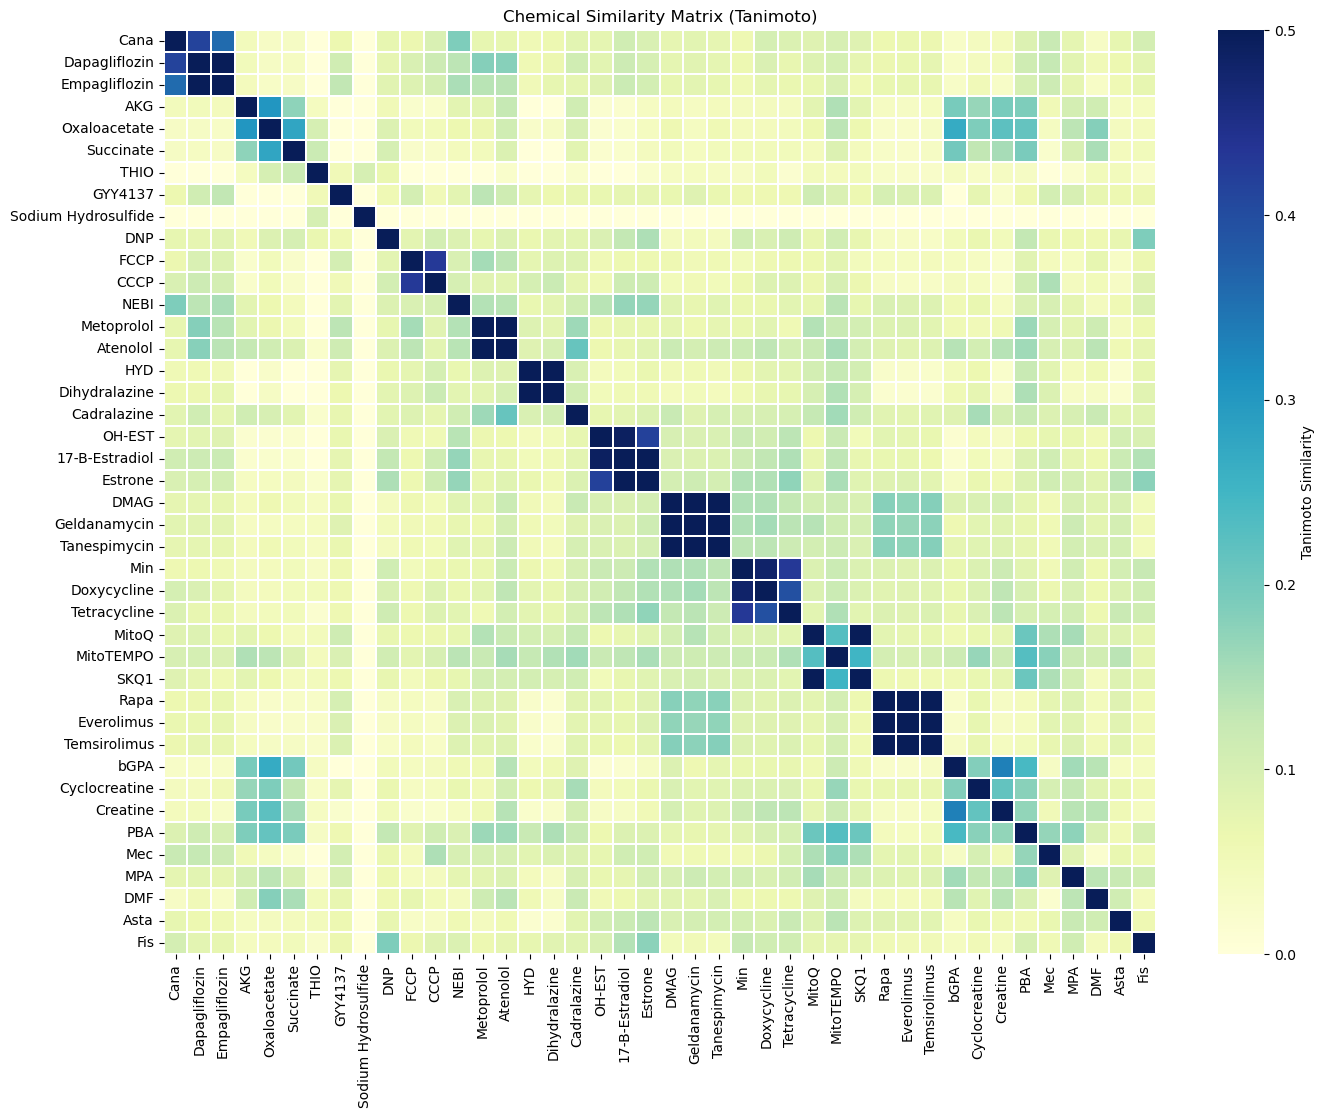

In [10]:
# Mapping your group labels to their SMILES strings
smiles_dict = {
    'Cana': 'CC1=C(C=C(C=C1)[C@H]2[C@@H]([C@H]([C@@H]([C@H](O2)CO)O)O)O)CC3=CC=C(S3)C4=CC=C(C=C4)F',
    'Dapagliflozin': 'CCOC1=CC=C(CC2=C(Cl)C=CC(=C2)[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)C=C1',
    'Empagliflozin':'OC[C@H]1O[C@H]([C@H](O)[C@@H](O)[C@@H]1O)C1=CC=C(Cl)C(CC2=CC=C(O[C@H]3CCOC3)C=C2)=C1',
    'AKG': 'C(C(C(=O)C(=O)O)O)C(=O)O',
    'Oxaloacetate':'OC(=O)CC(=O)C(O)=O',
    'Succinate':'C(CC(=O)[O-])C(=O)[O-]',
    'THIO': '[Na+].[Na+].[O-]S([O-])(=O)=S',
    'GYY4137':'COC1=CC=C(C=C1)P(=S)(N2CCOCC2)S',
    'Sodium Hydrosulfide':'[Na+].[SH-]',
    'DNP': 'C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])O',
    'FCCP':'C1=CC(=CC=C1NN=C(C#N)C#N)OC(F)(F)F',
    'CCCP':'C1=CC(=CC(=C1)Cl)NN=C(C#N)C#N',
    'NEBI': 'C1CC2=C(C=CC(=C2)F)OC1C(CNCC(C3CCC4=C(O3)C=CC(=C4)F)O)O',
    'Metoprolol':'CC(C)NCC(COC1=CC=C(C=C1)CCOC)O',
    'Atenolol':'CC(C)NCC(COC1=CC=C(C=C1)CC(=O)N)O',
    'HYD': 'C1=CC=C2C(=C1)C=NN=C2NN',
    'Dihydralazine':'C1=CC=C2C(=C1)C(=NN=C2NN)NN',
    'Cadralazine':'CCN(CC(C)O)C1=NN=C(C=C1)NNC(=O)OCC',
    'OH-EST': '[2H]C1=CC2=C(CC[C@@H]3[C@@H]2CC[C@]4([C@H]3C[C@H]([C@]4([2H])O)O)C)C(=C1O)[2H]',
    '17-B-Estradiol':'C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3C=CC(=C4)O',
    'Estrone':'C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=C3C=CC(=C4)O',
    'DMAG': 'CO[C@H]1C[C@H](C)CC2=C(NCCN(C)C)C(=O)C=C(NC(=O)\\C(C)=C\\C=C/[C@H](OC)[C@@H](OC(N)=O)\\C(C)=C\\[C@H](C)[C@H]1O)C2=O',
    'Geldanamycin':'C[C@H]1C[C@@H]([C@@H]([C@H](/C=C(/[C@@H]([C@H](/C=C\\C=C(\\C(=O)NC2=CC(=O)C(=C(C1)C2=O)OC)/C)OC)OC(=O)N)\\C)C)O)OC',
    'Tanespimycin':'C[C@H]1C[C@@H]([C@@H]([C@H](/C=C(/[C@@H]([C@H](/C=C\\C=C(\\C(=O)NC2=CC(=O)C(=C(C1)C2=O)NCC=C)/C)OC)OC(=O)N)\\C)C)O)OC',
    'Min': '[H][C@@]12CC3=C(C(O)=CC=C3N(C)C)C(=O)C1=C(O)[C@]1(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@]1([H])C2',
    'Doxycycline':'O.C[C@@H]1[C@H]2[C@H](O)[C@H]3[C@H](N(C)C)C(O)=C(C(N)=O)C(=O)[C@@]3(O)C(O)=C2C(=O)c4c(O)cccc14',
    'Tetracycline':'C[C@@]1([C@H]2C[C@H]3[C@@H](C(=O)C(=C([C@]3(C(=O)C2=C(C4=C1C=CC=C4O)O)O)O)C(=O)N)N(C)C)O',
    'MitoQ': 'COC1=C(OC)C(=O)C(CCCCCCCCCC[P+](C2=CC=CC=C2)(C2=CC=CC=C2)C2=CC=CC=C2)=C(C)C1=O',
    'MitoTEMPO':'CC1(CC(CC(N1[O])(C)C)NC(=O)C[P+](C2=CC=CC=C2)(C3=CC=CC=C3)C4=CC=CC=C4)C.[Cl-]',
    'SKQ1':'CC1=C(C(=O)C(=CC1=O)CCCCCCCCCC[P+](C2=CC=CC=C2)(C3=CC=CC=C3)C4=CC=CC=C4)C.[Br-]',
    'Rapa': '[H][C@@]1(C[C@@H](C)[C@]2([H])CC(=O)[C@H](C)\\C=C(C)\\[C@@H](O)[C@@H](OC)C(=O)[C@H](C)C[C@H](C)\\C=C\\C=C\\C=C(C)\\[C@H](C[C@]3([H])CC[C@@H](C)[C@@](O)(O3)C(=O)C(=O)N3CCCC[C@@]3([H])C(=O)O2)OC)CC[C@@H](O)[C@@H](C1)OC',
    'Everolimus':'C[C@@H]1CC[C@H]2C[C@@H](/C(=C/C=C/C=C/[C@H](C[C@H](C(=O)[C@@H]([C@@H](/C(=C/[C@H](C(=O)C[C@H](OC(=O)[C@@H]3CCCCN3C(=O)C(=O)[C@@]1(O2)O)[C@H](C)C[C@@H]4CC[C@H]([C@@H](C4)OC)OCCO)C)/C)O)OC)C)C)/C)OC',
    'Temsirolimus':'C[C@@H]1CC[C@H]2C[C@@H](/C(=C/C=C/C=C/[C@H](C[C@H](C(=O)[C@@H]([C@@H](/C(=C/[C@H](C(=O)C[C@H](OC(=O)[C@@H]3CCCCN3C(=O)C(=O)[C@@]1(O2)O)[C@H](C)C[C@@H]4CC[C@H]([C@@H](C4)OC)OC(=O)C(C)(CO)CO)C)/C)O)OC)C)C)/C)OC',
    'bGPA': 'NC(=N)NCCC(O)=O',
    'Cyclocreatine':'C1CN(C(=N1)N)CC(=O)O',
    'Creatine':'CN(CC(=O)O)C(=N)N',
    # New Cohort Drugs
    #SG1002 is a prodrug of H2S, but we don't have a specific structure for.
    'PBA':'OC(=O)CCCC1=CC=CC=C1',
    'Mec':'CC1=CC(CN2CCN(CC2)C(C2=CC=CC=C2)C2=CC=C(Cl)C=C2)=CC=C1',
    'MPA':'COC1=C(C\C=C(/C)CCC(O)=O)C(O)=C2C(=O)OCC2=C1C',
    'DMF':'[H]\C(=C(\[H])C(=O)OC)C(=O)OC',
    'Asta':'C\C(\C=C\C=C(/C)\C=C\C1=C(C)C(=O)[C@@H](O)CC1(C)C)=C/C=C/C=C(\C)/C=C/C=C(\C)/C=C/C1=C(C)C(=O)[C@@H](O)CC1(C)C',
    'Fis':'OC1=CC2=C(C=C1)C(=O)C(O)=C(O2)C1=CC=C(O)C(O)=C1'
}

mols = {name: Chem.MolFromSmiles(smi) for name, smi in smiles_dict.items()}

# Generate fingerprints
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2)
fps = {name: gen.GetFingerprint(mol) for name, mol in mols.items() if mol}

names = list(fps.keys())
drug_similarity_matrix = []

for name1 in names:
    row = []
    for name2 in names:
        sim = DataStructs.TanimotoSimilarity(fps[name1], fps[name2])
        row.append(sim)
    drug_similarity_matrix.append(row)

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(16, 12))
sns.heatmap(
    drug_similarity_matrix, 
    annot=False,
    xticklabels=names, 
    yticklabels=names, 
    cmap='YlGnBu', 
    vmax=0.5,
    linewidths=0.1,
    cbar_kws={'label': 'Tanimoto Similarity'}
)
plt.title('Chemical Similarity Matrix (Tanimoto)')
plt.show()

### Pathway Similarity Matrix

Fetching gene lists for 15 unique KEGG pathways...


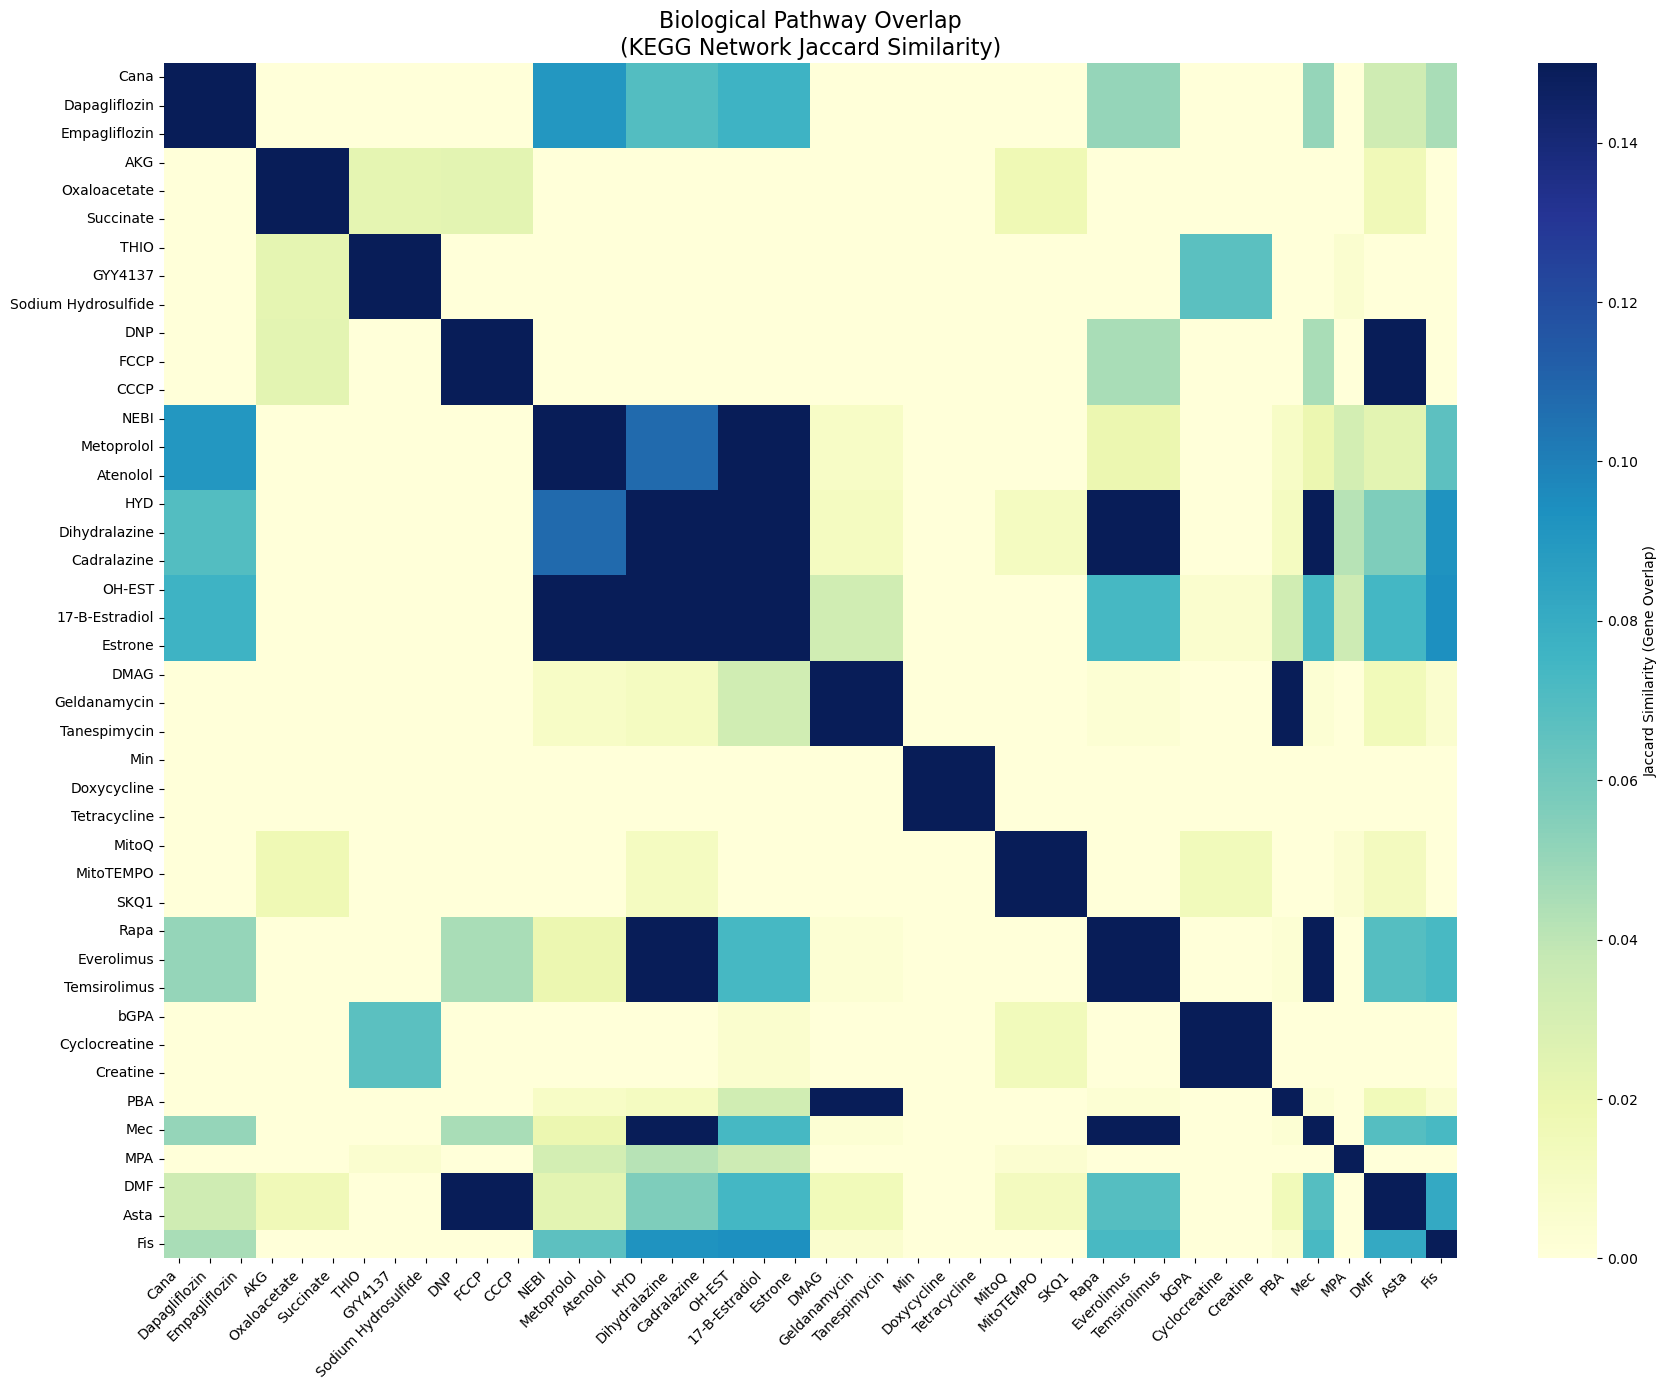

In [ ]:
# Map your drugs to actual KEGG Mouse (mmu) Pathway IDs
kegg_map = {
    'Cana': 'path:mmu04973', 'Dapagliflozin': 'path:mmu04973', 'Empagliflozin': 'path:mmu04973', #  mmu04964 (Proximal tubule bicarbonate reclamation) 
    'AKG': 'path:mmu00020', 'Oxaloacetate': 'path:mmu00020', 'Succinate': 'path:mmu00020',         
    'THIO': 'path:mmu00270', 'GYY4137': 'path:mmu00270', 'Sodium Hydrosulfide': 'path:mmu00270',   
    'DNP': 'path:mmu00190', 'FCCP': 'path:mmu00190', 'CCCP': 'path:mmu00190',                      
    'NEBI': 'path:mmu04261', 'Metoprolol': 'path:mmu04261', 'Atenolol': 'path:mmu04261',           
    'HYD': 'path:mmu04211', 'Dihydralazine': 'path:mmu04211', 'Cadralazine': 'path:mmu04211',      
    'OH-EST': 'path:mmu04915', '17-B-Estradiol': 'path:mmu04915', 'Estrone': 'path:mmu04915',      
    'DMAG': 'path:mmu04141', 'Geldanamycin': 'path:mmu04141', 'Tanespimycin': 'path:mmu04141',     
    'Min': 'path:mmu04512', 'Doxycycline': 'path:mmu04512', 'Tetracycline': 'path:mmu04512', # mmu03010 (Ribosome) or OxPhos (mmu00190)     
    'MitoQ': 'path:mmu04146', 'MitoTEMPO': 'path:mmu04146', 'SKQ1': 'path:mmu04146', #  mmu04216 (Ferroptosis) or mmu05208 (Chemical carcinogenesis – ROS)             
    'Rapa': 'path:mmu04150', 'Everolimus': 'path:mmu04150', 'Temsirolimus': 'path:mmu04150',       
    'bGPA': 'path:mmu00330', 'Cyclocreatine': 'path:mmu00330', 'Creatine': 'path:mmu00330',
    'PBA': 'path:mmu04141', 'Mec': 'path:mmu04150', 'MPA': 'path:mmu00230', 'DMF': 'path:mmu05208', 
    'Asta': 'path:mmu05208', 'Fis': 'path:mmu04218'    
}

# Add descriptive names to map alongside KEGG IDs for plotting
pathway_names = {
    'path:mmu04973': 'Carbohydrate Digestion',
    'path:mmu00020': 'TCA Cycle',
    'path:mmu00270': 'Cys/Met Metabolism',
    'path:mmu00190': 'Oxidative Phosphorylation',
    'path:mmu04261': 'Adrenergic Signaling',
    'path:mmu04211': 'Longevity (Nrf2)',
    'path:mmu04915': 'Estrogen Signaling',
    'path:mmu04141': 'Protein Processing (ER)',
    'path:mmu04512': 'ECM-Receptor Interaction',
    'path:mmu04146': 'Peroxisome',
    'path:mmu04150': 'mTOR Signaling',
    'path:mmu00330': 'Arg/Pro Metabolism',
    'path:mmu00230': 'Purine Metabolism', 
    'path:mmu05208': 'Chemical Carcinogenesis – ROS (Nrf2)',
    'path:mmu04218': 'Cellular Senescence'
}

def get_kegg_genes(pathway_id):
    url = f"http://rest.kegg.jp/link/mmu/{pathway_id}"
    try:
        response = requests.get(url, timeout=10)
        if response.ok:
            lines = response.text.strip().split('\n')
            return set([line.split('\t')[1] for line in lines if '\t' in line])
    except Exception as e:
        pass
    return set()

unique_pathways = list(set(kegg_map.values()))
print(f"Fetching gene lists for {len(unique_pathways)} unique KEGG pathways...")
pathway_genes = {pid: get_kegg_genes(pid) for pid in unique_pathways}

# Jaccard Similarity for all drugs based on their pathway
drugs = list(kegg_map.keys())
n = len(drugs)
target_similarity_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        set_A = pathway_genes[kegg_map[drugs[i]]]
        set_B = pathway_genes[kegg_map[drugs[j]]]
        
        intersection = len(set_A.intersection(set_B))
        union = len(set_A.union(set_B))
        if union > 0:
            target_similarity_matrix[i, j] = intersection / union

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(18, 14))
sns.heatmap(
    target_similarity_matrix, 
    annot=False,
    xticklabels=drugs, 
    yticklabels=drugs, 
    cmap="YlGnBu",
    vmax=0.15,
    cbar_kws={'label': 'Jaccard Similarity (Gene Overlap)'}
)
plt.title('Biological Pathway Overlap\n(KEGG Network Jaccard Similarity)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Build the Incomplete Drug-Pathway Lifespan Matrix

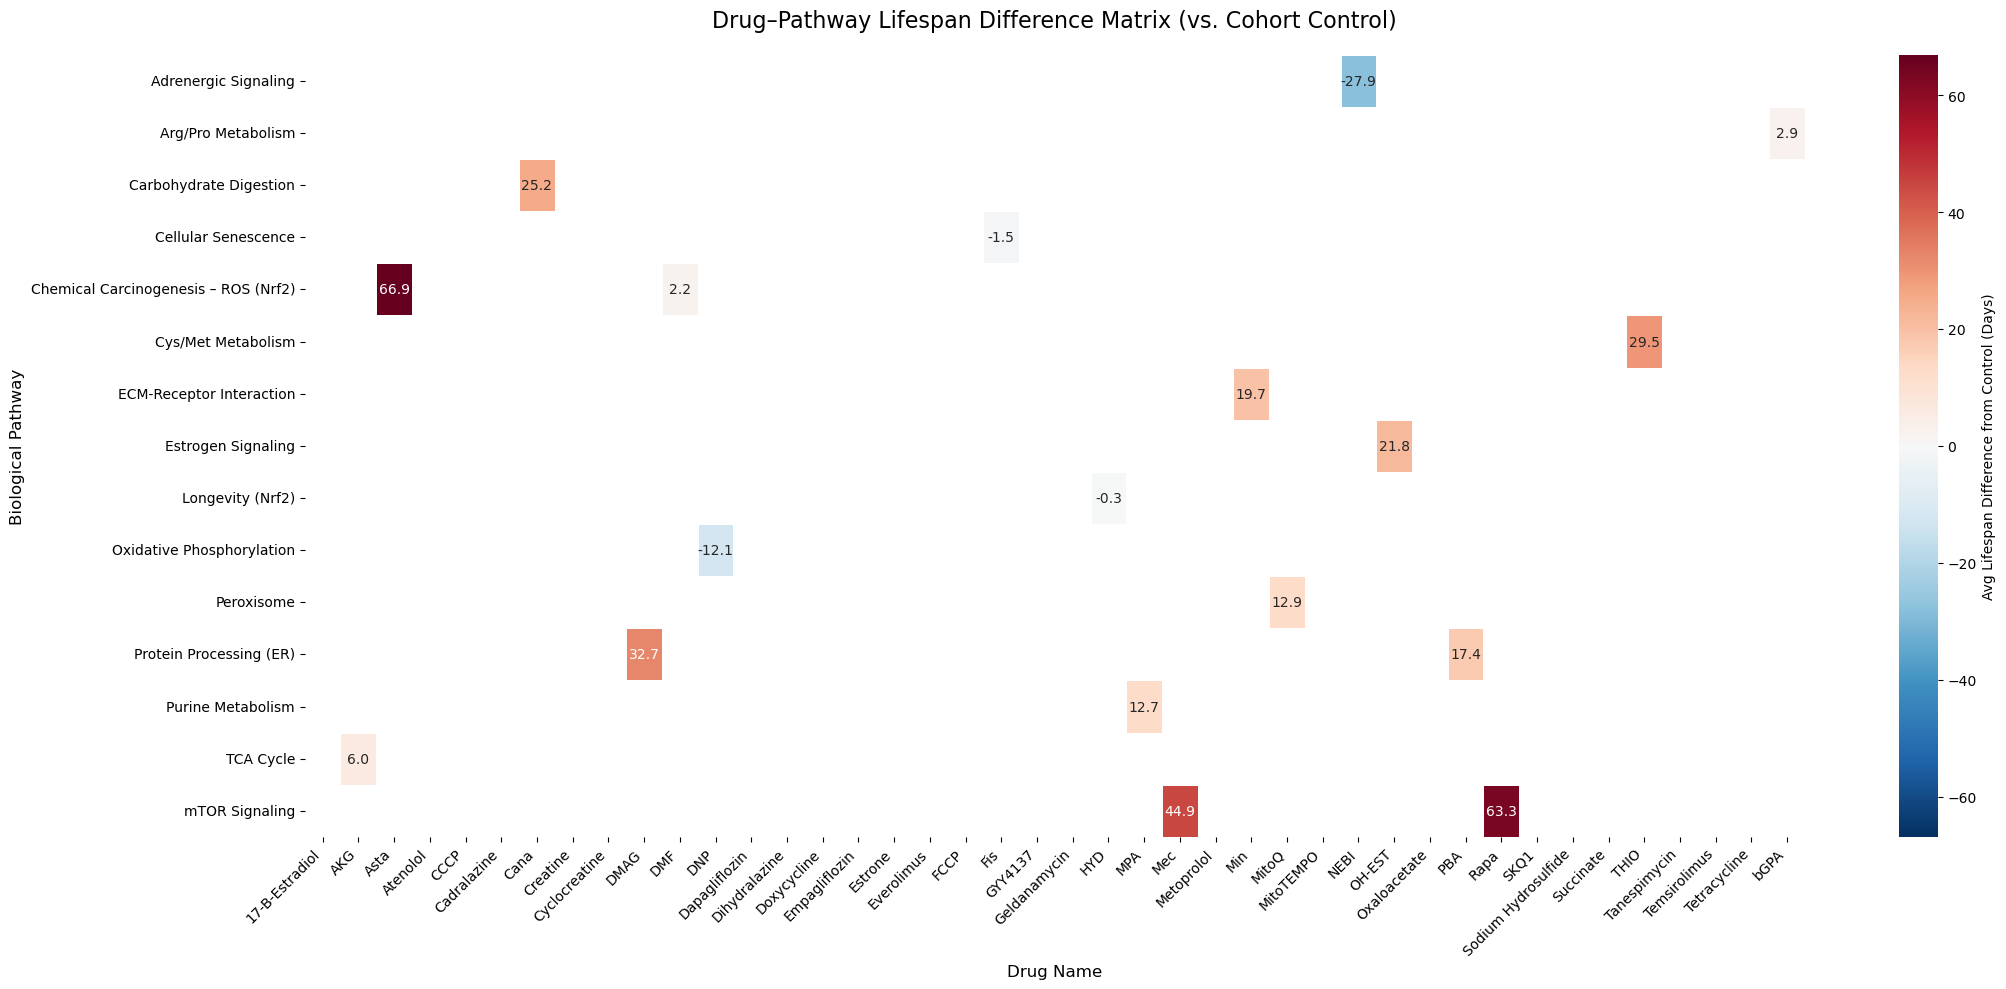

In [13]:
# 1. Skeleton so all drugs are represented
skeleton = pd.DataFrame([
    {'base_drug': drug, 'Pathway': pathway}
    for drug, pathway in drug_to_pathway_name.items()
])

# 2. Extract real data from combined_df
#    Note: combined_df must already have 'age_diff' computed from earlier
combined_df['base_drug'] = combined_df['group'].apply(
    lambda x: next((d for d in drug_to_pathway_name.keys() if d in str(x)), None)
)
combined_df['Pathway'] = combined_df['base_drug'].map(drug_to_pathway_name)

# Average DIFFERENCE-FROM-CONTROL per drug/pathway combination
matrix_data = (
    combined_df.dropna(subset=['base_drug'])
    .groupby(['base_drug', 'Pathway'])['age_diff']
    .mean()
    .reset_index()
)

# 3. Merge real data into skeleton
matrix_data = skeleton.merge(matrix_data, on=['base_drug', 'Pathway'], how='left')

# 4. Pivot for the heatmap
pivot_matrix = matrix_data.pivot(index='Pathway', columns='base_drug', values='age_diff')
pivot_matrix = pivot_matrix.drop(columns='Control', errors='ignore')
mask = pivot_matrix.isnull()

# ==========================================
# Visualization
# ==========================================
# Diverging colormap centered at 0 makes more sense for differences
vmax = pivot_matrix.abs().max().max()

plt.figure(figsize=(22, 10))
sns.heatmap(
    pivot_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0,
    vmin=-vmax, vmax=vmax,
    linewidths=.5,
    mask=mask,
    cbar_kws={'label': 'Avg Lifespan Difference from Control (Days)'}
)
plt.title('Drug–Pathway Lifespan Difference Matrix (vs. Cohort Control)', fontsize=16, pad=20)
plt.xlabel('Drug Name', fontsize=12)
plt.ylabel('Biological Pathway', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Matrix Completion

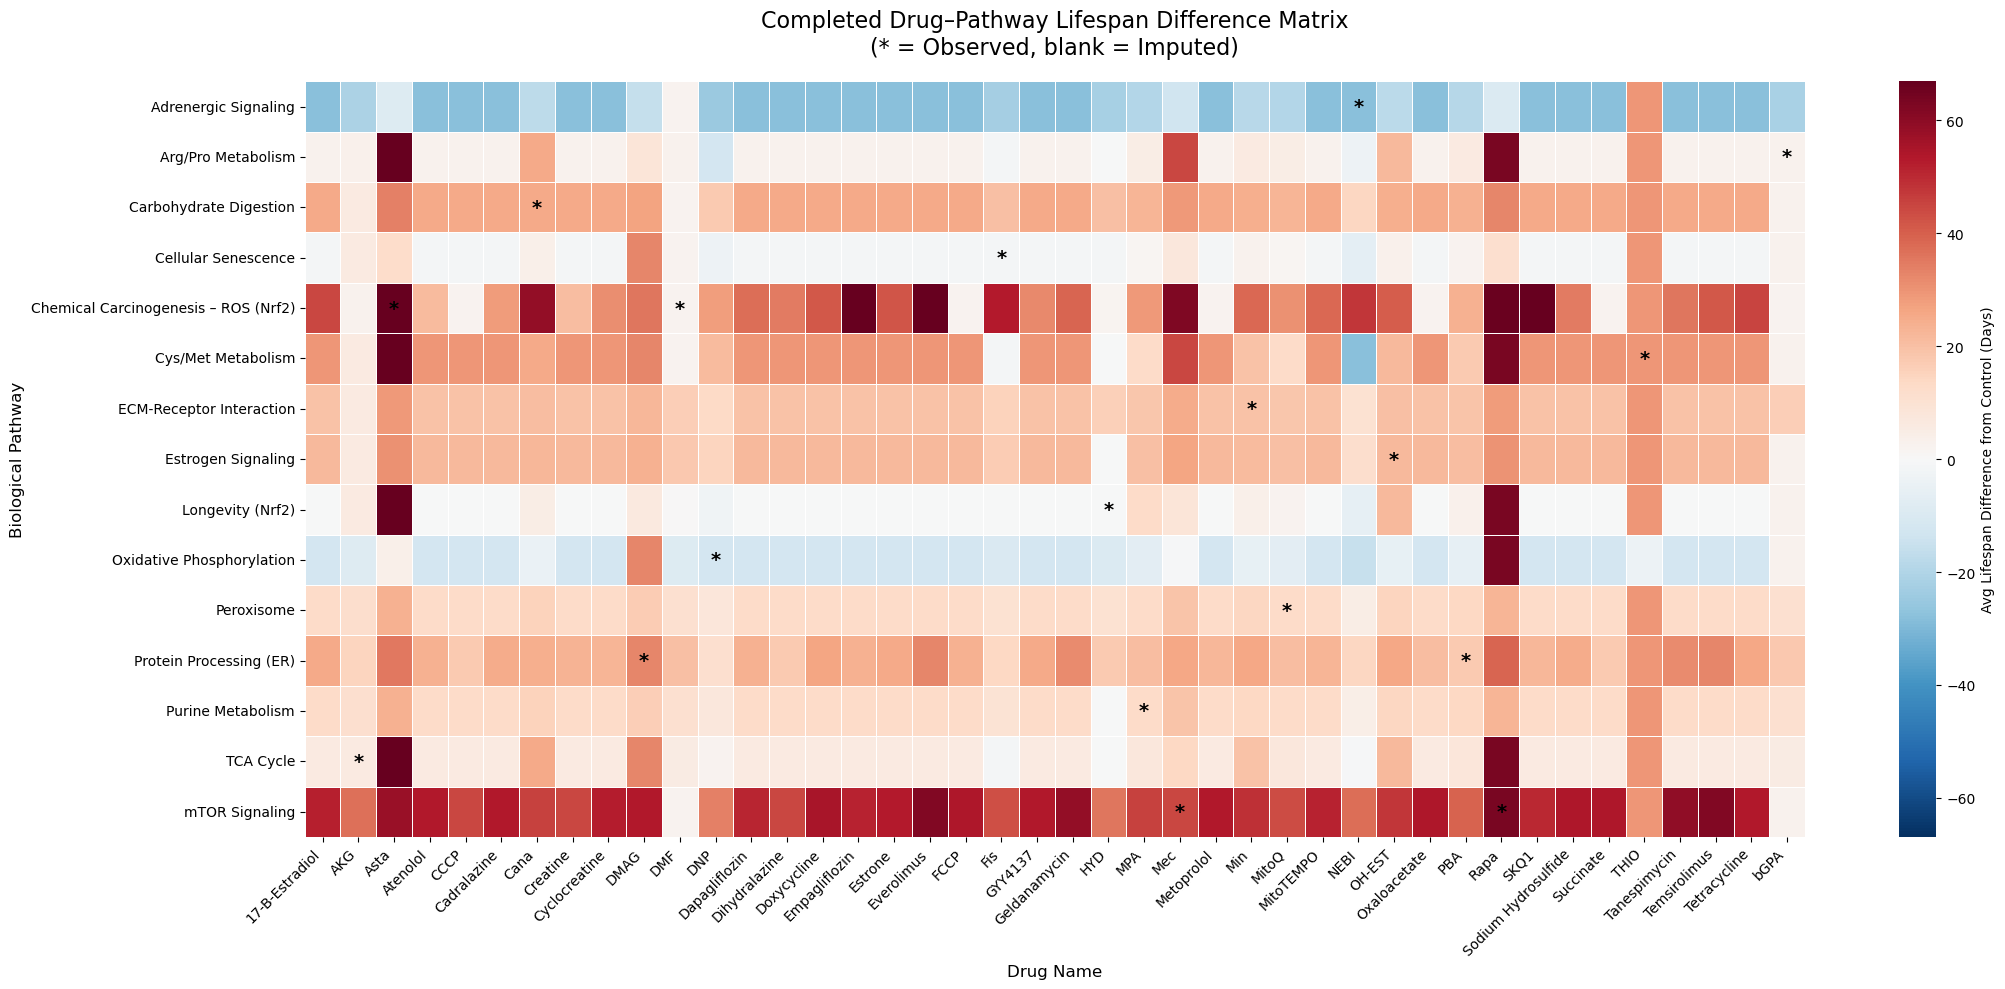

In [18]:
# ==========================================
# Matrix Preparation for Completion
# ==========================================

R_df = pivot_matrix.T 
drug_list = R_df.index.tolist()
pathway_list = R_df.columns.tolist()

m = len(pathway_list)
Sp_df = pd.DataFrame(np.zeros((m, m)), index=pathway_list, columns=pathway_list)

name_to_kegg = {v: k for k, v in pathway_names.items()}

for p1 in pathway_list:
    for p2 in pathway_list:
        pid1 = name_to_kegg.get(p1)
        pid2 = name_to_kegg.get(p2)
        
        set_A = pathway_genes.get(pid1, set())
        set_B = pathway_genes.get(pid2, set())
        
        intersection = len(set_A.intersection(set_B))
        union = len(set_A.union(set_B))
        Sp_df.loc[p1, p2] = (intersection / union) if union > 0 else 0.0

Sd_df = pd.DataFrame(drug_similarity_matrix, index=names, columns=names)
Sd_df = Sd_df.loc[drug_list, drug_list]

# ==========================================
# Matrix Completion Function
# ==========================================

def complete_matrix_smart(R, Sd, Sp, alpha=0.5, drug_sim_threshold=0.2):
    R_mat = R.values
    
    # 1. Filter out weak noise in Drug Similarity (Thresholding)
    Sd_mat = Sd.values.copy()
    Sd_mat[Sd_mat < drug_sim_threshold] = 0.0
    Sp_mat = Sp.values.copy()
    
    mask = ~np.isnan(R_mat)
    R_zeroed = np.nan_to_num(R_mat)
    
    # Set diagonals to 0 so we don't predict a value using its own missing cell
    np.fill_diagonal(Sd_mat, 0)
    np.fill_diagonal(Sp_mat, 0)
    
    # 2. Drug-based prediction (Row-wise)
    denom_d = Sd_mat.dot(mask.astype(float)) 
    Pd = np.zeros_like(R_zeroed)
    valid_d = denom_d > 0
    Pd[valid_d] = Sd_mat.dot(R_zeroed)[valid_d] / denom_d[valid_d]
    
    # 3. Pathway-based prediction (Column-wise)
    denom_p = mask.astype(float).dot(Sp_mat)
    Pp = np.zeros_like(R_zeroed)
    valid_p = denom_p > 0
    Pp[valid_p] = R_zeroed.dot(Sp_mat)[valid_p] / denom_p[valid_p]
    
    # 4. Dynamic Combination
    P_combined = np.zeros_like(R_zeroed)
    
    for i in range(R_mat.shape[0]):
        for j in range(R_mat.shape[1]):
            if not mask[i, j]:  # If it is a missing value we need to predict
                has_d = valid_d[i, j]
                has_p = valid_p[i, j]
                
                # If we have both signals, blend them based on alpha
                if has_d and has_p:
                    P_combined[i, j] = alpha * Pd[i, j] + (1 - alpha) * Pp[i, j]
                # If we only have structural drug similarities, rely 100% on that
                elif has_d:
                    P_combined[i, j] = Pd[i, j]
                # If we only have biological pathway similarities, rely 100% on that
                elif has_p:
                    P_combined[i, j] = Pp[i, j]
                # Absolute fallback if an isolated drug hits an isolated pathway
                else:
                    col_mean = np.nanmean(R_mat[:, j])
                    P_combined[i, j] = col_mean if not np.isnan(col_mean) else np.nanmean(R_mat)
            else:
                # Keep the actual observed data
                P_combined[i, j] = R_mat[i, j]
                
    return pd.DataFrame(P_combined, index=R.index, columns=R.columns)

Sp_df = Sp_df + 0.01 
completed_R_df = complete_matrix_smart(R_df, Sd_df, Sp_df, alpha=0.8, drug_sim_threshold=0.05)

# ==========================================
# Visualization
# ==========================================
annot_labels = []
for i in range(len(completed_R_df.index)):
    row = []
    for j in range(len(completed_R_df.columns)):
        is_real = not np.isnan(R_df.iloc[i, j])
        row.append("*" if is_real else "")
    annot_labels.append(row)

completed_R_plot = completed_R_df.T
annot_plot = np.array(annot_labels).T

vmax = completed_R_plot.abs().max().max()

plt.figure(figsize=(22, 10))
sns.heatmap(
    completed_R_plot,
    annot=annot_plot,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-vmax, vmax=vmax,
    linewidths=.5,
    annot_kws={'fontsize': 14, 'fontweight': 'bold', 'color': 'black'},
    cbar_kws={'label': 'Avg Lifespan Difference from Control (Days)'}
)
plt.title('Completed Drug–Pathway Lifespan Difference Matrix\n(* = Observed, blank = Imputed)', fontsize=16, pad=20)
plt.xlabel('Drug Name', fontsize=12)
plt.ylabel('Biological Pathway', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()